# Learn++ Implementation from Scratch

This notebook implements the Learn++ algorithm (Polikar et al., 2001) step by step.
Each section maps directly to the equations in `planning_seed/06_LEARNPP_ALGORITHM.md`.

## Why from scratch?
- Full understanding of internals for presentation and report
- Step-by-step comments explaining each decision
- Easy to modify for our specific comparison (MLP vs Decision Tree)

## Hardware
- Local: RTX A1000 + i9 (sufficient for this scale)

## Dependencies
```
numpy, scikit-learn, matplotlib, seaborn
```

In [1]:
%pip install ipykernel scikit-learn matplotlib numpy seaborn


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1. Learn++ Algorithm Overview

Learn++ is an **ensemble-based incremental learning** algorithm. It:
1. Receives data in sequential batches (D₁, D₂, D₃, ...)
2. Trains multiple weak hypotheses on each batch
3. Combines all hypotheses via weighted majority voting
4. Never discards old hypotheses — knowledge accumulates

### Key Idea
Each batch trains T_k base learners. Samples that are hard to classify get higher weights
(like AdaBoost), but across batches the ensemble only grows — it never forgets.

### Core Equations
| Symbol | Meaning |
|--------|---------|
| D_k | k-th data batch |
| T_k | Number of base learners trained on batch k |
| h_t | Base hypothesis (classifier) at iteration t |
| ε_t | Weighted error of h_t |
| β_t | Confidence weight = ε_t / (1 - ε_t) |
| w_i | Sample weight for instance i |
| H_final | Final ensemble (weighted majority vote) |

## 2. Base Learner Definitions

We compare two base learners within Learn++:

| Learner | Origin | Key Params | Why |
|---------|--------|-----------|-----|
| MLP (Multi-Layer Perceptron) | Original Learn++ paper (Polikar et al., 2001) | hidden_layers=(50,), max_iter=200 | The classifier used in the original paper for OCR |
| Decision Tree | Later Learn++ variants (Learn++.NSE, 2011) | max_depth=5 | Recommended for MRI/medical data; interpretable |

**Historical note**: The original Learn++ (2001) used MLP/SLP as base classifiers for optical character recognition. Decision Trees were adopted in later variants like Learn++.NSE (Elwell & Polikar, 2011). Gradient Boosting was never used in the original Learn++ papers (it is itself an ensemble of trees, creating a nested-ensemble if placed inside Learn++).

In [3]:
def make_paper_learner():
    """MLP (Multi-Layer Perceptron) — the original Learn++ base classifier.
    
    Why MLP?
    - This is the classifier from the original Learn++ paper (Polikar et al., 2001)
    - Used for OCR (optical character recognition) in the paper
    - Neural network with higher capacity than a single decision tree
    - Assignment requires using one algorithm from the paper
    - Question: does the original paper's classifier still outperform
      a tree-based model on our medical imaging task?
    """
    return MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,  # 500 iters to allow convergence (200 was too few)
        random_state=RANDOM_SEED
    )


def make_recommended_learner():
    """Decision Tree — base learner from later Learn++ variants (Learn++.NSE, 2011).
    
    Why Decision Tree?
    - Used in Learn++.NSE (Elwell & Polikar, 2011) as a proven base learner
    - Research shows strong performance on medical/MRI data
    - Interpretable: we can inspect what features drive splits
    - Fast to train, low memory footprint
    - Works well with ROI-based tabular features from BraTS
    """
    return DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_SEED
    )
def make_recommended_learner_but_stronger():
    """Decision Tree — base learner from later Learn++ variants (Learn++.NSE, 2011).
    
    Why Decision Tree?
    - Used in Learn++.NSE (Elwell & Polikar, 2011) as a proven base learner
    - Research shows strong performance on medical/MRI data
    - Interpretable: we can inspect what features drive splits
    - Fast to train, low memory footprint
    - Works well with ROI-based tabular features from BraTS
    """
    return DecisionTreeClassifier(
        max_depth=300,
        random_state=RANDOM_SEED
    )

## 3. Learn++ Implementation

### Step-by-step:
1. **Initialize** sample weights uniformly
2. **For each iteration t** in batch k:
   - Draw a weighted subset from the batch (using sample weights as distribution)
   - Train base learner h_t on the subset
   - Compute weighted error ε_t on the FULL batch
   - If ε_t ≥ 0.5: discard h_t, re-initialize weights, retry
   - Compute confidence: β_t = ε_t / (1 - ε_t)
   - Update sample weights: reduce weights of correctly classified samples
   - Normalize weights
3. **After all batches**: final prediction = weighted majority vote across all h_t

In [4]:
class LearnPP:
    """Learn++ incremental learning algorithm.
    
    Reference: Polikar, R., Upda, L., Upda, S.S., & Honavar, V. (2001).
    Learn++: An incremental learning algorithm for supervised neural networks.
    IEEE Transactions on Systems, Man, and Cybernetics.
    """
    
    def __init__(self, base_learner_factory, T_k=10, max_retries=3):
        """
        Args:
            base_learner_factory: Callable that returns a fresh base learner instance.
            T_k: Number of base learners to train per batch.
            max_retries: Max attempts if a hypothesis has error >= 0.5.
        """
        self.base_learner_factory = base_learner_factory
        self.T_k = T_k
        self.max_retries = max_retries
        
        # Accumulated ensemble across all batches
        self.hypotheses = []   # List of trained base learners
        self.betas = []        # Confidence weight for each hypothesis
        self.classes_ = None   # Known class labels
    
    def partial_fit(self, X, y):
        """Train on a new batch of data (incremental learning step).
        
        This is called once per batch D_k. The ensemble grows by T_k hypotheses.
        Old hypotheses are NEVER removed — this is how Learn++ avoids forgetting.
        
        Args:
            X: Feature matrix for this batch, shape (n_samples, n_features)
            y: Labels for this batch, shape (n_samples,)
        """
        n_samples = len(X)
        
        # Track all known classes across batches
        if self.classes_ is None:
            self.classes_ = np.unique(y)
        else:
            self.classes_ = np.unique(np.concatenate([self.classes_, np.unique(y)]))
        
        # --- Eq. 1: Initialize sample weights uniformly ---
        # Every sample starts equally important
        w = np.ones(n_samples) / n_samples

        # init_dist
        if len(self.hypotheses) > 0:
            H_init = self.predict(X)
            E_init = np.sum(w[H_init != y])
            
            # Bound error to prevent division by zero
            E_init = np.clip(E_init, 1e-10, 1.0 - 1e-10)
            B_init = E_init / (1 - E_init)
            
            # Reduce weights of correctly classified instances
            correct_init = (H_init == y).astype(float)
            w = w * (B_init ** correct_init)

            # Safe normalization
           
    
        for t in range(self.T_k):

            for retry in range(self.max_retries):
                # --- Eq. 2: Create training distribution D_t from weights ---
                # Normalize weights; handle potential all-zero case
                sum_w = np.sum(w)
                if sum_w < 1e-15:
                    w = np.ones(n_samples) / n_samples
                    sum_w = 1.0
                D_t = w / sum_w

                indices = np.random.choice(
                    n_samples, size=n_samples, replace=True, p=D_t
                )
                X_train, y_train = X[indices], y[indices]
                
                # --- Eq. 3: Train base hypothesis h_t ---
                h_t = self.base_learner_factory()
                h_t.fit(X_train, y_train)
                
                # --- Eq. 4: Compute weighted error on FULL batch ---
                predictions = h_t.predict(X)
                incorrect = (predictions != y).astype(float)
                epsilon_t = np.dot(D_t, incorrect)  # Weighted error
                
                # --- Eq. 4: Check error condition ---
                # If error >= 0.5, this hypothesis is no better than random
                if epsilon_t < 0.5:
                    break  # Good hypothesis, proceed
            else:
                # All retries failed — skip this iteration
                continue
            
            # --- Eq. 6: Compute confidence weight ---
            beta_t = epsilon_t / (1 - epsilon_t + 1e-10)  # Small epsilon for stability
            
            # Store hypothesis and its confidence
            self.hypotheses.append(h_t)
            self.betas.append(beta_t)
            
            # --- Step 6: Compute error of the composite hypothesis E_t ---
            H_t_predictions = self.predict(X)
            incorrect_H_t = (H_t_predictions != y).astype(float)
            e_t = np.dot(D_t, incorrect_H_t)
            
            # --- Eq. 7: Update sample weights opierając się na komitecie H_t ---
            b_t = e_t / (1 - e_t + 1e-10)  

            # Redukujemy wagi wyłącznie próbek poprawnie zdiagnozowanych przez ZESPÓŁ
            correct_H_t = (H_t_predictions == y).astype(float)
            w = w * (b_t ** correct_H_t) 

            




    def predict(self, X):
        """Predict using weighted majority vote across ALL hypotheses.
        
        Each hypothesis votes for a class. Votes are weighted by log(1/beta).
        The class with the highest total vote wins.
        """
        if not self.hypotheses:
            raise RuntimeError("No hypotheses trained yet. Call partial_fit first.")
        
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        
        # Vote accumulator: shape (n_samples, n_classes)
        votes = np.zeros((n_samples, n_classes))
        
        for h_t, beta_t in zip(self.hypotheses, self.betas):
            # Vote weight = log(1 / beta_t)
            # Lower beta (better classifier) = higher vote weight
            vote_weight = np.log(1.0 / (beta_t + 1e-10))
            
            predictions = h_t.predict(X)
            for i, pred in enumerate(predictions):
                class_idx = np.where(self.classes_ == pred)[0]
                if len(class_idx) > 0:
                    votes[i, class_idx[0]] += vote_weight
        
        # Final prediction = class with highest accumulated vote
        return self.classes_[np.argmax(votes, axis=1)]

## 4. Quick Validation on Synthetic Data

Before running on Fashion-MNIST or BraTS, let's verify the implementation works
on a simple 2D classification problem with incremental batches.

In [5]:
from sklearn.datasets import make_classification

# Create a simple dataset split into 3 batches
X_full, y_full = make_classification(
    n_samples=900, n_features=10, n_classes=3,
    n_informative=6, random_state=RANDOM_SEED
)

# Split into 3 incremental batches
batches = [
    (X_full[:300], y_full[:300]),    # D1
    (X_full[300:600], y_full[300:600]),  # D2
    (X_full[600:], y_full[600:]),    # D3
]

# Holdout test set
X_test, y_test = make_classification(
    n_samples=300, n_features=10, n_classes=3,
    n_informative=6, random_state=RANDOM_SEED + 1
)

print(f"Batches: {[b[0].shape[0] for b in batches]} samples each")
print(f"Test set: {X_test.shape[0]} samples")

Batches: [300, 300, 300] samples each
Test set: 300 samples


In [6]:
# Run Learn++ with MLP (original paper's classifier)
import warnings
model_mlp = LearnPP(base_learner_factory=make_paper_learner, T_k=10)

print("=== Learn++ with MLP (original paper, Polikar 2001) ===")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for k, (X_batch, y_batch) in enumerate(batches, 1):
        model_mlp.partial_fit(X_batch, y_batch)
        y_pred = model_mlp.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        ba = balanced_accuracy_score(y_test, y_pred)
        print(f"  After D{k}: MacroF1={f1:.3f}, BalancedAcc={ba:.3f}, "
              f"Ensemble size={len(model_mlp.hypotheses)}")

=== Learn++ with MLP (original paper, Polikar 2001) ===
  After D1: MacroF1=0.240, BalancedAcc=0.261, Ensemble size=10
  After D2: MacroF1=0.244, BalancedAcc=0.240, Ensemble size=20
  After D3: MacroF1=0.284, BalancedAcc=0.280, Ensemble size=30


In [7]:
# Run Learn++ with Decision Tree (from Learn++.NSE, recommended for MRI)
model_dt = LearnPP(base_learner_factory=make_recommended_learner, T_k=10)

print("=== Learn++ with Decision Tree (Learn++.NSE, 2011 — recommended for MRI) ===")
for k, (X_batch, y_batch) in enumerate(batches, 1):
    model_dt.partial_fit(X_batch, y_batch)
    y_pred = model_dt.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    ba = balanced_accuracy_score(y_test, y_pred)
    print(f"  After D{k}: MacroF1={f1:.3f}, BalancedAcc={ba:.3f}, "
          f"Ensemble size={len(model_dt.hypotheses)}")

=== Learn++ with Decision Tree (Learn++.NSE, 2011 — recommended for MRI) ===
  After D1: MacroF1=0.311, BalancedAcc=0.351, Ensemble size=10
  After D2: MacroF1=0.296, BalancedAcc=0.331, Ensemble size=20
  After D3: MacroF1=0.320, BalancedAcc=0.358, Ensemble size=30


## 5. Next Steps

Once this validation passes:
1. **EXP-01**: Load Fashion-MNIST, design batches per `04_DATA_STRATEGY.md`, run comparison
2. **EXP-02**: Load BraTS, extract ROI features, run comparison
3. **Metrics**: Compute full CompositeScore (quality + cost)
4. **Statistics**: Wilcoxon signed-rank test for significance

See `planning_seed/03_EXPERIMENT_PLAN.md` for the full protocol.

In [8]:
import gzip, struct, os
from pathlib import Path
from urllib.request import urlretrieve

def load_fashion_mnist(data_dir="data/fashion_mnist"):
    """Download Fashion-MNIST from GitHub (bypasses blocked OpenML API)."""
    base_url = "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/"
    files = {
        "train_images": "train-images-idx3-ubyte.gz",
        "train_labels": "train-labels-idx1-ubyte.gz",
        "test_images":  "t10k-images-idx3-ubyte.gz",
        "test_labels":  "t10k-labels-idx1-ubyte.gz",
    }
    Path(data_dir).mkdir(parents=True, exist_ok=True)
    
    for name, fname in files.items():
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            print(f"  Downloading {fname}...")
            urlretrieve(base_url + fname, fpath)
    
    def read_images(path):
        with gzip.open(path, 'rb') as f:
            _, n, rows, cols = struct.unpack('>IIII', f.read(16))
            return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)
    
    def read_labels(path):
        with gzip.open(path, 'rb') as f:
            struct.unpack('>II', f.read(8))
            return np.frombuffer(f.read(), dtype=np.uint8)
    
    X_train = read_images(os.path.join(data_dir, files["train_images"]))
    y_train = read_labels(os.path.join(data_dir, files["train_labels"]))
    X_test = read_images(os.path.join(data_dir, files["test_images"]))
    y_test = read_labels(os.path.join(data_dir, files["test_labels"]))
    return X_train, y_train, X_test, y_test

print("Loading Fashion-MNIST from GitHub...")
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_fashion_mnist()

X_fmnist = np.vstack([X_train_raw, X_test_raw]) / 255.0
y_fmnist = np.hstack([y_train_raw, y_test_raw]).astype(int)
dataset_name = "Fashion-MNIST"

print(f"\nDataset: {dataset_name}")
print(f"Shape: {X_fmnist.shape}")
print(f"Classes: {np.unique(y_fmnist)}")
print(f"Samples per class: {[np.sum(y_fmnist == c) for c in np.unique(y_fmnist)]}")

Loading Fashion-MNIST from GitHub...

Dataset: Fashion-MNIST
Shape: (70000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]
Samples per class: [np.int64(7000), np.int64(7000), np.int64(7000), np.int64(7000), np.int64(7000), np.int64(7000), np.int64(7000), np.int64(7000), np.int64(7000), np.int64(7000)]


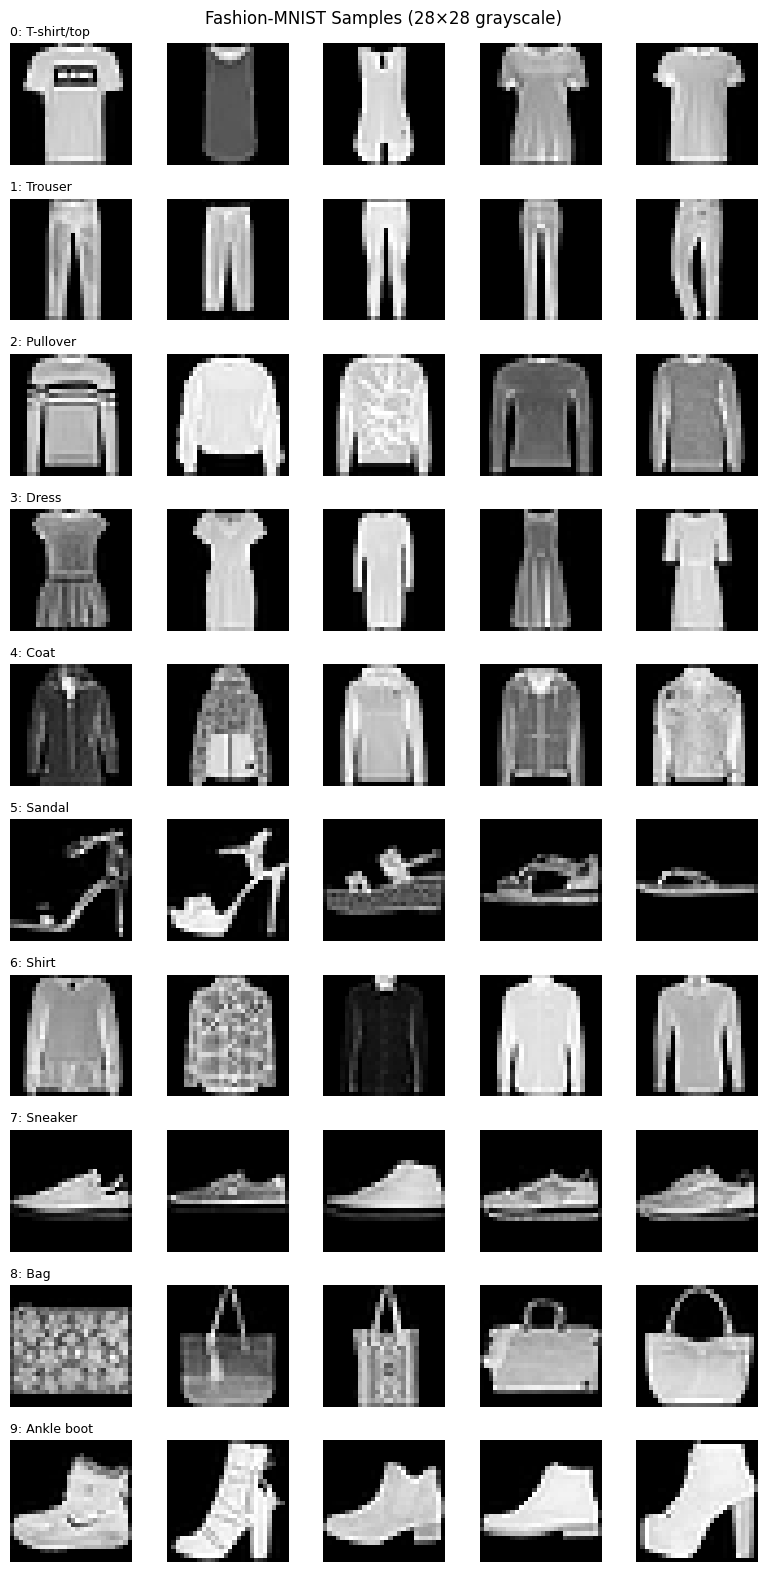


Saved to: data\fashion_mnist\sample_images
Files:
  class_0_T-shirt_top.png
  class_1_Trouser.png
  class_2_Pullover.png
  class_3_Dress.png
  class_4_Coat.png
  class_5_Sandal.png
  class_6_Shirt.png
  class_7_Sneaker.png
  class_8_Bag.png
  class_9_Ankle boot.png
  fashion_mnist_grid.png


In [9]:
# --- Save sample Fashion-MNIST images as viewable PNGs ---
from pathlib import Path

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

out_dir = Path("data/fashion_mnist/sample_images")
out_dir.mkdir(parents=True, exist_ok=True)

# Save a grid: 5 examples per class (10 classes × 5 = 50 images in one figure)
fig, axes = plt.subplots(10, 5, figsize=(8, 16))
for class_idx in range(10):
    mask = y_train_raw == class_idx
    samples = X_train_raw[mask][:5]
    for col in range(5):
        ax = axes[class_idx, col]
        ax.imshow(samples[col].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(f"{class_idx}: {class_names[class_idx]}", fontsize=9, loc='left')

plt.suptitle("Fashion-MNIST Samples (28×28 grayscale)", fontsize=12)
plt.tight_layout()
plt.savefig(str(out_dir / "fashion_mnist_grid.png"), dpi=150, bbox_inches='tight')
plt.show()

# Also save individual PNGs for each class (first example)
for class_idx in range(10):
    mask = y_train_raw == class_idx
    img = X_train_raw[mask][0].reshape(28, 28)
    plt.imsave(str(out_dir / f"class_{class_idx}_{class_names[class_idx].replace('/', '_')}.png"), 
               img, cmap='gray')

print(f"\nSaved to: {out_dir}")
print("Files:")
for f in sorted(out_dir.glob("*.png")):
    print(f"  {f.name}")

In [10]:
# --- Optional PCA dimensionality reduction ---
# Fashion-MNIST at 784 dims is highly redundant. PCA to 50 components:
# - Preserves ~95% of variance
# - Makes MLP ~15x faster to train (50 vs 784 input features)
# - Scientifically sound preprocessing (not cheating)
# Set USE_PCA = False to run on raw pixels (slower but pure)

from sklearn.decomposition import PCA

USE_PCA = True
N_COMPONENTS = 50

if USE_PCA:
    print(f"Applying PCA: {X_fmnist.shape[1]} → {N_COMPONENTS} dimensions...")
    pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_SEED)
    X_fmnist_pca = pca.fit_transform(X_fmnist)
    explained = pca.explained_variance_ratio_.sum()
    print(f"  Explained variance: {explained:.1%}")
    print(f"  New shape: {X_fmnist_pca.shape}")
    # Replace the dataset
    X_fmnist = X_fmnist_pca
else:
    print("PCA disabled — using raw 784-dim pixels (slow for MLP)")

Applying PCA: 784 → 50 dimensions...
  Explained variance: 86.3%
  New shape: (70000, 50)


In [71]:
import numpy as np 

# --- Create incremental batches (simulate class introduction) ---
# Use the standard Fashion-MNIST train/test split
X_train_all, y_train_all = X_fmnist[:60000], y_fmnist[:60000]
X_test_all, y_test_all = X_fmnist[60000:], y_fmnist[60000:]

# === Non-optimal batch design (disjoint + all-class refresh) ===
# D1: Classes 0-3, D2: Classes 4-6, D3: Classes 7-9, D4: All classes
batch_classes_not_optimal = [
    [0, 1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 
]

# Build non-optimal batches (simple mask-based, allows sample reuse across batches)
batches_fmnist = []
for classes in batch_classes_not_optimal:
    mask = np.isin(y_train_all, classes)
    batches_fmnist.append((X_train_all[mask], y_train_all[mask]))

print('Non-optimal (disjoint + refresh) batches:')
for i, (X_b, y_b) in enumerate(batches_fmnist, 1):
    print(f'  D{i}: {len(X_b)} samples, classes {np.unique(y_b)}')

# === Optimal batch design (cumulative, no sample reuse) ===
# Each batch adds new classes cumulatively; samples used once are not reused
batch_classes = [
    [0, 1, 2, 3],
    [0, 1, 2, 3, 4, 5, 6],  
    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 
]



# #class indices are used to keep track of which samples belong to which class in the training set. This allows us to efficiently create batches of data that contain specific classes without having to search through the entire dataset each time.
# class_indices = {c: np.where(y_train_all == c)[0] for c in np.unique(y_train_all)}

# batches_fmnist_optimal = []

# for classes in batch_classes:
#     indices_to_use = []

#     for c in classes:
#         idx = class_indices[c].tolist()
#         indices_to_use.extend(idx)
#         class_indices[c] = np.array([], dtype=int)
    
#     indices_array = np.array(indices_to_use, dtype=int)
    
#     if indices_array.size > 0:
#         batches_fmnist_optimal.append((X_train_all[indices_array], y_train_all[indices_array]))
#     else:
#         # Opcjonalnie: dodaj pusty batch, jeśli chcesz zachować strukturę 1:1
#         batches_fmnist_optimal.append((np.array([]), np.array([])))


# batches_fmnist = []
# for classes in batch_classes_not_optimal:
#     mask = np.isin(y_train_all, classes)
#     batches_fmnist.append((X_train_all[mask], y_train_all[mask]))

# print('Non-optimal (disjoint + refresh) batches:')
# for i, (X_b, y_b) in enumerate(batches_fmnist, 1):
#     print(f'  D{i}: {len(X_b)} samples, classes {np.unique(y_b)}')
        
import time
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score


import numpy as np
from collections import Counter

def construct_batches_cumulative_list(X, y, list_of_batches):
    """Divides data based on cumulative class lists, ensuring no repetition across batches.
    Each batch in list_of_batches is a list of classes that should be included in that batch.
    Additionally, shuffles the final samples within each batch so classes are mixed.
    """
    class_appearances = Counter([cls for batch in list_of_batches for cls in batch])
  
    shuffled_indices = {cls: np.random.permutation(np.where(y == cls)[0]) for cls in class_appearances.keys()}
    pointers = {cls: 0 for cls in class_appearances.keys()}
    
    final_batches = []
    for batch_classes in list_of_batches:
        batch_X, batch_y = [], []
        for cls in batch_classes:
            total_needed = class_appearances[cls]
            count_for_this_batch = len(shuffled_indices[cls]) // total_needed
            
            start = pointers[cls]
            end = start + count_for_this_batch
            
            # Fetch data
            indices = shuffled_indices[cls][start:end]
            batch_X.append(X[indices])
            batch_y.append(y[indices])
            pointers[cls] = end
            
        if batch_X:  # Check if the batch is not empty
            # Concatenate class blocks into a single array
            np_X = np.concatenate(batch_X)
            np_y = np.concatenate(batch_y)
            
            # Generate random indices to mix classes within the batch
            shuffle_idx = np.random.permutation(len(np_y))
            
            final_batches.append((np_X[shuffle_idx], np_y[shuffle_idx]))
            
    return final_batches

def construct_batches_from_dist_dict(X, y, distribution):
    """Divides data based on a distribution dictionary, ensuring no repetition across batches.
    Additionally, shuffles the final samples within each batch so classes are mixed.
    """
    shuffled_indices = {cls: np.random.permutation(np.where(y == cls)[0]) for cls in distribution.keys()}
    pointers = {cls: 0 for cls in distribution.keys()}
    
    # Find the number of batches (max from the list of values in the dictionary)
    num_batches = max([len(v) for v in distribution.values()])
    batches_X = [[] for _ in range(num_batches)]
    batches_y = [[] for _ in range(num_batches)]
    
    for cls, counts in distribution.items():
        indices = shuffled_indices[cls]
        for batch_idx, count in enumerate(counts):
            if count > 0:
                start = pointers[cls]
                end = start + count
                selected_idx = indices[start:end]
                batches_X[batch_idx].extend(X[selected_idx])
                batches_y[batch_idx].extend(y[selected_idx])
                pointers[cls] = end
    
    final_batches = []
    for bX, bY in zip(batches_X, batches_y):
        if len(bX) > 0:
            # Convert to NumPy arrays
            np_X = np.array(bX)
            np_Y = np.array(bY)
            
            # Generate random indices to mix classes within the batch
            shuffle_idx = np.random.permutation(len(np_Y))
            
            final_batches.append((np_X[shuffle_idx], np_Y[shuffle_idx]))
            
    return final_batches


# --- DEFINICJE SCENARIUSZY ---
ocr_distribution = {
    0: [100, 50, 50, 25], 1: [0, 150, 50, 0],
    2: [100, 50, 50, 25], 3: [0, 150, 50, 25],
    4: [100, 50, 50, 0], 5: [0, 150, 50, 25],
    6: [100, 50, 0, 100], 7: [0, 0, 150, 50],
    8: [100, 0, 0, 150], 9: [0, 50, 100, 50]
}

batch_classes_cumulative = [
    [0, 2, 4],
    [0, 2, 6, 1, 5],
    [0, 8, 4, 6, 1, 3, 7, 9],
    [4, 6, 1, 3, 5, 9,8 ]
]

batch_classes_dist = [
    [0, 2, 4, 6, 8],
    [0, 2, 4, 6, 1, 3, 5, 9],
    [0, 2, 4, 1, 3, 5, 9, 7],
    [0, 2, 6, 8, 3, 5, 9, 7]
]

batch_classes_no_rep = [
    [0, 2, 4, 6, 8],
    [1,3,5],
    [7,9],
    [0,1,3,4,8,7]
]


Non-optimal (disjoint + refresh) batches:
  D1: 24000 samples, classes [0 1 2 3]
  D2: 18000 samples, classes [4 5 6]
  D3: 18000 samples, classes [7 8 9]
  D4: 60000 samples, classes [0 1 2 3 4 5 6 7 8 9]
  Skipping batch 4: empty (all samples already used)

Optimal (cumulative, no reuse) batches: 3 non-empty
  D1: 24000 samples, classes [0 1 2 3]
  D2: 18000 samples, classes [4 5 6]
  D3: 18000 samples, classes [7 8 9]


### 5.1 Run EXP-01: MLP (from paper) vs Decision Tree (recommended)

We run both classifiers through Learn++ on the same Fashion-MNIST batch sequence.
For each, we measure:
- **MacroF1** and **BalancedAccuracy** after each batch (quality)
- **Training time** per batch (cost)
- **Total ensemble size** (memory proxy)

In [12]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
import time
import numpy as np

def run_experiment(learner_factory, learner_name, batches, X_test, y_test, T_k=10, seed=42):
    np.random.seed(seed)
    model = LearnPP(base_learner_factory=learner_factory, T_k=T_k)
    
    num_batches = len(batches)
    class_perf = np.zeros((num_batches, num_batches))
    gen_perf = []
    
    results = {
        'learner': learner_name, 'seed': seed,
        'batch_f1': [], 'batch_ba': [], 'batch_acc': [],
        'batch_train_time': [], 'batch_inference_time': [],
        'ensemble_sizes': [],
    }
    
    for k, (X_batch, y_batch) in enumerate(batches):
        # Trening
        t0 = time.time()
        model.partial_fit(X_batch, y_batch)
        train_time = time.time() - t0
        
       
        for j in range(k + 1):
            X_eval, y_eval = batches[j]
            preds = model.predict(X_eval)
            class_perf[j, k] = accuracy_score(y_eval, preds)
            
      
        t0 = time.time()
        test_preds = model.predict(X_test)
        inference_time = time.time() - t0
        
      
        test_acc = accuracy_score(y_test, test_preds)
        test_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
        test_ba = balanced_accuracy_score(y_test, test_preds)
        
        gen_perf.append(test_acc) 
        
        results['batch_acc'].append(test_acc)
        results['batch_f1'].append(test_f1)
        results['batch_ba'].append(test_ba)
        
        # Zapis logów czasowych i rozmiaru
        results['batch_train_time'].append(train_time)
        results['batch_inference_time'].append(inference_time)
        results['ensemble_sizes'].append(len(model.hypotheses))
        
    results['total_train_time'] = sum(results['batch_train_time'])
    results['total_inference_time'] = sum(results['batch_inference_time'])
    
    results['final_acc'] = results['batch_acc'][-1]
    results['final_f1'] = results['batch_f1'][-1]
    results['final_ba'] = results['batch_ba'][-1]
    
    results['class_perf'] = class_perf
    results['gen_perf'] = gen_perf
    
    return results

def run_multi_seed(learner_factory, learner_name, batches, X_test, y_test, T_k=10, seeds=None):
    if seeds is None:
        seeds = [42, 123, 456, 789, 1024]
    return [run_experiment(learner_factory, learner_name, batches, X_test, y_test, T_k=T_k, seed=s) for s in seeds]

In [13]:

def print_learnpp_table(class_perf, gen_perf, model_name, seed):
    num_batches = len(gen_perf)
    print(f"\n=== Learn++ Results Table for {model_name} (Seed: {seed}) ===")
    
  
    header = f"{'Dataset':<10} | " + " | ".join([f"TS{k+1}      " for k in range(num_batches)])
    print(header)
    print("-" * len(header))

    # Wiersze dla S1, S2, S3...
    for j in range(num_batches):
        row_str = f"S{j+1:<8} | "
        for i in range(num_batches):
            if i >= j:
                row_str += f"{class_perf[j][i]*100:6.2f}% | "
            else:
                row_str += "        | "
        print(row_str)

    print("-" * len(header))
    
   
    test_row = f"{'TEST':<10} | "
    for i in range(num_batches):
        test_row += f"{gen_perf[i]*100:6.2f}% | "
    print(test_row)
    print("=" * len(header))

In [14]:
batches_1 = construct_batches_cumulative_list(X_train_all, y_train_all, batch_classes_cumulative)
batches_2 = construct_batches_from_dist_dict(X_train_all, y_train_all, ocr_distribution)
batches_3 = construct_batches_cumulative_list(X_train_all, y_train_all, batch_classes_dist)
batches_4 = construct_batches_cumulative_list(X_train_all, y_train_all, batch_classes_no_rep)


results = [
    run_experiment(learner_factory=make_paper_learner, learner_name="Decision Tree", batches=batches_1, X_test=X_test_all, y_test=y_test_all),
    run_experiment(learner_factory=make_paper_learner, learner_name="Decision Tree", batches=batches_2, X_test=X_test_all, y_test=y_test_all),
    run_experiment(learner_factory=make_paper_learner, learner_name="Decision Tree", batches=batches_3, X_test=X_test_all, y_test=y_test_all),
    run_experiment(learner_factory=make_paper_learner, learner_name="Decision Tree", batches=batches_4, X_test=X_test_all, y_test=y_test_all)
]
titles = [
    "Cumulative (Set 1) introducing classes in own, different order",
    "Table 10 (Dict)",
    "Cumulative (Set 2) introducing classes in the same order as in the article",
    "No Repetition"
]

for r, title in zip(results, titles):
    print(f"\n=== {title} ===")
    
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']*100:5.2f}%, F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")


/Users/magda/Desktop/Informatyka/SEM_5/sem6/ML_project/ML_project/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/magda/Desktop/Informatyka/SEM_5/sem6/ML_project/ML_project/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/magda/Desktop/Informatyka/SEM_5/sem6/ML_project/ML_project/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/magda/Desktop/Informatyka/SEM_5/sem6/ML_project/ML_project/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multi


=== Cumulative (Set 1) introducing classes in own, different order ===
  Seed   42: Acc=76.52%, F1=0.7262, BalAcc=0.7652, TrainTime=376.0s

=== Table 10 (Dict) ===
  Seed   42: Acc=79.13%, F1=0.7936, BalAcc=0.7913, TrainTime=14.0s

=== Cumulative (Set 2) introducing classes in the same order as in the article ===
  Seed   42: Acc=87.34%, F1=0.8728, BalAcc=0.8734, TrainTime=424.4s

=== No Repetition ===
  Seed   42: Acc=49.88%, F1=0.4292, BalAcc=0.4988, TrainTime=292.8s


In [ ]:
batches_1 = construct_batches_cumulative_list(X_train_all, y_train_all, batch_classes_cumulative)
batches_2 = construct_batches_from_dist_dict(X_train_all, y_train_all, ocr_distribution)
batches_3 = construct_batches_cumulative_list(X_train_all, y_train_all, batch_classes_dist)
batches_4 = construct_batches_cumulative_list(X_train_all, y_train_all, batch_classes_no_rep)


results = [
    run_experiment(learner_factory=make_recommended_learner, learner_name="Decision Tree", batches=batches_1, X_test=X_test_all, y_test=y_test_all),
    run_experiment(learner_factory=make_recommended_learner, learner_name="Decision Tree", batches=batches_2, X_test=X_test_all, y_test=y_test_all),
    run_experiment(learner_factory=make_recommended_learner, learner_name="Decision Tree", batches=batches_3, X_test=X_test_all, y_test=y_test_all),
    run_experiment(learner_factory=make_recommended_learner, learner_name="Decision Tree", batches=batches_4, X_test=X_test_all, y_test=y_test_all)
]
titles = [
    "Cumulative (Set 1) introducing classes in own, different order",
    "Table 10 (Dict)",
    "Cumulative (Set 2) introducing classes in the same order as in the article",
    "No Repetition"
]

for r, title in zip(results, titles):
    print(f"\n=== {title} ===")
    
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']*100:5.2f}%, F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")



=== Cumulative (Set 1) introducing classes in own, different order ===
  Seed   42: Acc=63.92%, F1=0.6068, BalAcc=0.6392, TrainTime=36.9s

=== Table 10 (Dict) ===
  Seed   42: Acc=71.68%, F1=0.7262, BalAcc=0.7168, TrainTime=1.1s

=== Cumulative (Set 2) introducing classes in the same order as in the article ===
  Seed   42: Acc=73.74%, F1=0.7393, BalAcc=0.7374, TrainTime=34.8s

=== No Repetition ===
  Seed   42: Acc=44.17%, F1=0.3792, BalAcc=0.4417, TrainTime=30.9s


In [73]:
batches_1 = construct_batches_cumulative_list(X_train_all, y_train_all, batch_classes_cumulative)
batches_2 = construct_batches_from_dist_dict(X_train_all, y_train_all, ocr_distribution)
batches_3 = construct_batches_cumulative_list(X_train_all, y_train_all, batch_classes_dist)
batches_4 = construct_batches_cumulative_list(X_train_all, y_train_all, batch_classes_no_rep)


results = [
    run_experiment(learner_factory=make_recommended_learner_but_stronger, learner_name="Decision Tree", batches=batches_1, X_test=X_test_all, y_test=y_test_all),
    run_experiment(learner_factory=make_recommended_learner_but_stronger, learner_name="Decision Tree", batches=batches_2, X_test=X_test_all, y_test=y_test_all),
    run_experiment(learner_factory=make_recommended_learner_but_stronger, learner_name="Decision Tree", batches=batches_3, X_test=X_test_all, y_test=y_test_all),
    run_experiment(learner_factory=make_recommended_learner_but_stronger, learner_name="Decision Tree", batches=batches_4, X_test=X_test_all, y_test=y_test_all)
]
titles = [
    "Cumulative (Set 1) introducing classes in own, different order",
    "Table 10 (Dict)",
    "Cumulative (Set 2) introducing classes in the same order as in the article",
    "No Repetition"
]

for r, title in zip(results, titles):
    print(f"\n=== {title} ===")
    
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']*100:5.2f}%, F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")



=== Cumulative (Set 1) introducing classes in own, different order ===
  Seed   42: Acc=73.58%, F1=0.7000, BalAcc=0.7358, TrainTime=57.1s

=== Table 10 (Dict) ===
  Seed   42: Acc=74.07%, F1=0.7415, BalAcc=0.7407, TrainTime=1.1s

=== Cumulative (Set 2) introducing classes in the same order as in the article ===
  Seed   42: Acc=82.92%, F1=0.8278, BalAcc=0.8292, TrainTime=54.2s

=== No Repetition ===
  Seed   42: Acc=57.14%, F1=0.5001, BalAcc=0.5714, TrainTime=45.0s


In [63]:
SEEDS = [42, 123, 456, 789, 1024]

print("=" * 80)
print(f"EXP-02a: Learn++ with MLP — {len(SEEDS)} seeds")
print("=" * 80)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    all_results_mlp = run_multi_seed(
        make_paper_learner, "MLP", batches_3, X_test_all, y_test_all, T_k=10, seeds=SEEDS
    )

for r in all_results_mlp:
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']*100:5.2f}%, F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")


EXP-02a: Learn++ with MLP — 5 seeds
  Seed   42: Acc=87.46%, F1=0.8740, BalAcc=0.8746, TrainTime=412.9s
  Seed  123: Acc=87.35%, F1=0.8727, BalAcc=0.8735, TrainTime=405.4s
  Seed  456: Acc=87.54%, F1=0.8747, BalAcc=0.8754, TrainTime=410.3s
  Seed  789: Acc=87.10%, F1=0.8703, BalAcc=0.8710, TrainTime=405.9s
  Seed 1024: Acc=87.22%, F1=0.8714, BalAcc=0.8722, TrainTime=601.6s


In [66]:


SEEDS = [42, 123, 456, 789, 1024]

print()
print("=" * 80)
print(f"EXP-02b: Learn++ with Decision Tree — {len(SEEDS)} seeds")
print("=" * 80)
all_results_dt = run_multi_seed(
    make_recommended_learner, "Decision Tree", batches_3, X_test_all, y_test_all, T_k=10, seeds=SEEDS
)

for r in all_results_dt:
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']*100:5.2f}%, F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")


results_mlp = all_results_mlp[0]
results_dt = all_results_dt[0]
print(f"\nUsing seed={SEEDS[0]} for detailed dataset performance tables below.")

print_learnpp_table(results_mlp['class_perf'], results_mlp['gen_perf'], "MLP", SEEDS[0])
print_learnpp_table(results_dt['class_perf'], results_dt['gen_perf'], "Decision Tree", SEEDS[0])


EXP-02b: Learn++ with Decision Tree — 5 seeds
  Seed   42: Acc=73.74%, F1=0.7393, BalAcc=0.7374, TrainTime=34.6s
  Seed  123: Acc=73.08%, F1=0.7338, BalAcc=0.7308, TrainTime=34.9s
  Seed  456: Acc=73.74%, F1=0.7415, BalAcc=0.7374, TrainTime=34.9s
  Seed  789: Acc=74.28%, F1=0.7458, BalAcc=0.7428, TrainTime=35.3s
  Seed 1024: Acc=74.24%, F1=0.7467, BalAcc=0.7424, TrainTime=34.6s

Using seed=42 for detailed dataset performance tables below.

=== Learn++ Results Table for MLP (Seed: 42) ===
Dataset    | TS1       | TS2       | TS3       | TS4      
----------------------------------------------------------
S1        |  96.31% |  88.34% |  70.41% |  86.34% | 
S2        |         |  92.51% |  90.31% |  91.19% | 
S3        |         |         |  97.76% |  94.65% | 
S4        |         |         |         |  94.33% | 
----------------------------------------------------------
TEST       |  39.18% |  74.70% |  81.21% |  87.46% | 

=== Learn++ Results Table for Decision Tree (Seed: 42) ===
Dat

In [37]:


SEEDS = [42, 123, 456, 789, 1024]

print("=" * 80)
print(f"EXP-02a: Learn++ with MLP — {len(SEEDS)} seeds")
print("=" * 80)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    all_results_dt_stronger = run_multi_seed(
        make_recommended_learner_but_stronger, "DT", batches_3, X_test_all, y_test_all, T_k=10, seeds=SEEDS
    )

for r in all_results_dt_stronger:
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']*100:5.2f}%, F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")



results_dt_stronger = all_results_dt_stronger[0]
print(f"\nUsing seed={SEEDS[0]} for detailed dataset performance tables below.")

print_learnpp_table(results_mlp['class_perf'], results_mlp['gen_perf'], "MLP", SEEDS[0])
print_learnpp_table(results_dt['class_perf'], results_dt['gen_perf'], "Decision Tree", SEEDS[0])
print_learnpp_table(results_dt_stronger['class_perf'], results_dt_stronger['gen_perf'], "Decision Tree Stronger", SEEDS[0])

EXP-02a: Learn++ with MLP — 5 seeds
  Seed   42: Acc=82.87%, F1=0.8272, BalAcc=0.8287, TrainTime=55.2s
  Seed  123: Acc=82.71%, F1=0.8259, BalAcc=0.8271, TrainTime=55.4s
  Seed  456: Acc=82.91%, F1=0.8273, BalAcc=0.8291, TrainTime=54.5s
  Seed  789: Acc=82.28%, F1=0.8215, BalAcc=0.8228, TrainTime=54.1s
  Seed 1024: Acc=82.84%, F1=0.8268, BalAcc=0.8284, TrainTime=53.1s

Using seed=42 for detailed dataset performance tables below.

=== Learn++ Results Table for MLP (Seed: 42) ===
Dataset    | TS1       | TS2       | TS3       | TS4      
----------------------------------------------------------
S1        |  96.31% |  88.34% |  70.41% |  86.34% | 
S2        |         |  92.51% |  90.31% |  91.19% | 
S3        |         |         |  97.76% |  94.65% | 
S4        |         |         |         |  94.33% | 
----------------------------------------------------------
TEST       |  39.18% |  74.70% |  81.21% |  87.46% | 

=== Learn++ Results Table for Decision Tree (Seed: 42) ===
Dataset    | T

### 5.2 Results Comparison

Compare both classifiers using:
- Per-batch performance plot
- CompositeScore formula: `0.40·MacroF1 + 0.15·BalancedAccuracy + 0.15·(1-TrainTimeNorm) + 0.15·(1-InferenceTimeNorm) + 0.15·(1-MemoryNorm)`
- Wilcoxon signed-rank test for statistical significance

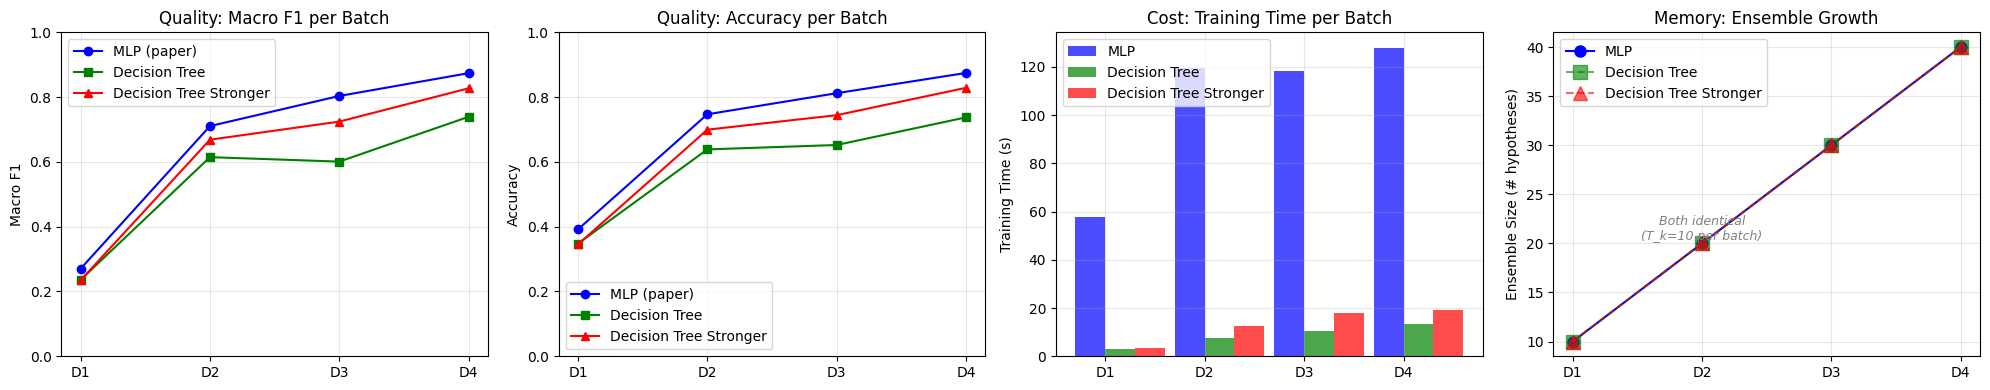

Figure saved to ../results/exp01_fashion_mnist_comparison_all.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../results', exist_ok=True)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

n_batches = len(results_mlp['batch_f1'])
batch_labels = [f"D{i+1}" for i in range(n_batches)]

mlp_f1 = results_mlp['batch_f1']
dt_f1 = results_dt['batch_f1']

mlp_f1 = results_mlp['batch_f1']
dt_f1 = results_dt['batch_f1']
dt_f1_stronger = results_dt_stronger['batch_f1']

mlp_acc = results_mlp['batch_acc']
dt_acc = results_dt['batch_acc']
dt_acc_stronger = results_dt_stronger['batch_acc']

mlp_time = results_mlp['batch_train_time']
dt_time = results_dt['batch_train_time']
dt_time_stronger = results_dt_stronger['batch_train_time']

mlp_ens = results_mlp['ensemble_sizes']
dt_ens = results_dt['ensemble_sizes']
dt_ens_stronger = results_dt_stronger['ensemble_sizes']

# 1. MacroF1 per batch
axes[0].plot(batch_labels, mlp_f1, 'o-', label='MLP (paper)', color='blue')
axes[0].plot(batch_labels, dt_f1, 's-', label='Decision Tree', color='green')
axes[0].plot(batch_labels, dt_f1_stronger, '^-', label='Decision Tree Stronger', color='red')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Macro F1 per Batch')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# 2. Accuracy per batch
axes[1].plot(batch_labels, mlp_acc, 'o-', label='MLP (paper)', color='blue')
axes[1].plot(batch_labels, dt_acc, 's-', label='Decision Tree', color='green')
axes[1].plot(batch_labels, dt_acc_stronger, '^-', label='Decision Tree Stronger', color='red')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy per Batch')
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

axes[2].bar(np.arange(4) - 0.15, mlp_time, 0.3, label='MLP', color='blue', alpha=0.7)
axes[2].bar(np.arange(4) + 0.15, dt_time, 0.3, label='Decision Tree', color='green', alpha=0.7)
axes[2].bar(np.arange(4) + 0.45, dt_time_stronger, 0.3, label='Decision Tree Stronger', color='red', alpha=0.7)
axes[2].set_xticks(range(4))
axes[2].set_xticklabels(batch_labels)
axes[2].set_ylabel('Training Time (s)')
axes[2].set_title('Training Time per Batch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Ensemble size
axes[3].plot(batch_labels, mlp_ens, 'o-', label='MLP', color='blue', markersize=8)
axes[3].plot(batch_labels, dt_ens, 's--', label='Decision Tree', color='green', 
             markersize=10, alpha=0.6)  
axes[3].plot(batch_labels, dt_ens_stronger, '^--', label='Decision Tree Stronger', color='red', 
             markersize=10, alpha=0.6)
axes[3].set_ylabel('Ensemble Size (# hypotheses)')
axes[3].set_title('Ensemble Growth')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.suptitle('EXP-01: Fashion-MNIST \u2014 Disjoint + All-Class Refresh (4 batches)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/exp01_fashion_mnist_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to results/exp01_fashion_mnist_comparison.png") 

In [33]:
# --- CompositeScore Calculation ---
# Formula: 0.40·MacroF1 + 0.15·BalancedAccuracy + 0.15·(1-TrainTimeNorm) + 0.15·(1-InferenceTimeNorm) + 0.15·(1-MemoryNorm)

def compute_composite_score(results_a, results_b, results_c):
    """Compute CompositeScore for both models using min-max normalization across the pair."""
    
    # Normalize cost metrics (0 = worst, 1 = best for each)
    # Training time: lower is better
    max_train = max(results_a['total_train_time'], results_b['total_train_time'], results_c['total_train_time'])
    min_train = min(results_a['total_train_time'], results_b['total_train_time'], results_c['total_train_time'])
    range_train = max_train - min_train if max_train != min_train else 1.0
    
    # Inference time: lower is better
    max_inf = max(results_a['total_inference_time'], results_b['total_inference_time'], results_c['total_inference_time'])
    min_inf = min(results_a['total_inference_time'], results_b['total_inference_time'], results_c['total_inference_time'])
    range_inf = max_inf - min_inf if max_inf != min_inf else 1.0
    
    # Memory (ensemble size): lower is better
    max_mem = max(results_a['ensemble_sizes'][-1], results_b['ensemble_sizes'][-1], results_c['ensemble_sizes'][-1])
    min_mem = min(results_a['ensemble_sizes'][-1], results_b['ensemble_sizes'][-1], results_c['ensemble_sizes'][-1])
    range_mem = max_mem - min_mem if max_mem != min_mem else 1.0
    
    scores = {}
    for name, r in [('MLP', results_a), ('Decision Tree', results_b), ('Decision Tree Stronger', results_c)]:
        f1 = r['final_f1']
        ba = r['final_ba']
        train_norm = (r['total_train_time'] - min_train) / range_train
        inf_norm = (r['total_inference_time'] - min_inf) / range_inf
        mem_norm = (r['ensemble_sizes'][-1] - min_mem) / range_mem
        
        composite = (0.40 * f1 + 
                     0.15 * ba + 
                     0.15 * (1 - train_norm) + 
                     0.15 * (1 - inf_norm) + 
                     0.15 * (1 - mem_norm))
        
        scores[name] = {
            'MacroF1': f1,
            'BalancedAcc': ba,
            'TrainTimeNorm': train_norm,
            'InferenceTimeNorm': inf_norm,
            'MemoryNorm': mem_norm,
            'CompositeScore': composite
        }
    
    return scores

scores = compute_composite_score(results_mlp, results_dt, results_dt_stronger)

print("\n" + "=" * 60)
print("COMPOSITE SCORE COMPARISON (EXP-01: Fashion-MNIST)")
print("=" * 60)
print(f"\n{'Metric':<22} {'MLP (paper)':>12} {'DT (recommended)':>18} {'DT Stronger':>18}")
print("-" * 75)
for metric in ['MacroF1', 'BalancedAcc', 'TrainTimeNorm', 'InferenceTimeNorm', 'MemoryNorm', 'CompositeScore']:
    mlp_val = scores['MLP'][metric]
    dt_val = scores['Decision Tree'][metric]
    dt_stronger_val = scores['Decision Tree Stronger'][metric]
    marker = " <-- winner" if metric == 'CompositeScore' else ""
    if metric == 'CompositeScore':
        winner = "MLP" if mlp_val > dt_val and mlp_val > dt_stronger_val else ("DT Stronger" if dt_stronger_val > dt_val else "DT")
        print("-" * 75)
        print(f"{'COMPOSITE SCORE':<22} {mlp_val:>12.4f} {dt_val:>18.4f} {dt_stronger_val:>18.4f}  ← {winner} wins")
    else:
        print(f"{metric:<22} {mlp_val:>12.4f} {dt_val:>18.4f} {dt_stronger_val:>18.4f}")
print(f"\nTotal train time:  MLP={results_mlp['total_train_time']:.1f}s, DT={results_dt['total_train_time']:.1f}s, DT Stronger={results_dt_stronger['total_train_time']:.1f}s")
print(f"Total inf. time:   MLP={results_mlp['total_inference_time']:.1f}s, DT={results_dt['total_inference_time']:.1f}s, DT Stronger={results_dt_stronger['total_inference_time']:.1f}s")


COMPOSITE SCORE COMPARISON (EXP-01: Fashion-MNIST)

Metric                  MLP (paper)   DT (recommended)        DT Stronger
---------------------------------------------------------------------------
MacroF1                      0.8740             0.7393             0.8272
BalancedAcc                  0.8746             0.7374             0.8287
TrainTimeNorm                1.0000             0.0000             0.0485
InferenceTimeNorm            1.0000             0.0000             0.2989
MemoryNorm                   0.0000             0.0000             0.0000
---------------------------------------------------------------------------
COMPOSITE SCORE              0.6308             0.8563             0.8531  ← DT wins

Total train time:  MLP=423.9s, DT=34.7s, DT Stronger=53.6s
Total inf. time:   MLP=1.7s, DT=1.4s, DT Stronger=1.5s


In [69]:
# --- Statistical Significance: Wilcoxon Signed-Rank Test (multi-seed) ---
from scipy.stats import wilcoxon

# Collect ALL per-batch F1 scores across all seeds → paired observations
# Each (seed, batch) pair gives one MLP score and one DT score
f1_mlp_all = np.array([f1 for r in all_results_mlp for f1 in r['batch_f1']])
f1_dt_all = np.array([f1 for r in all_results_dt for f1 in r['batch_f1']])

n_pairs = len(f1_mlp_all)
print(f"Paired observations: {n_pairs} ({len(SEEDS)} seeds × {len(batches_3)} batches)")
print(f"\nMLP F1 scores:  mean={f1_mlp_all.mean():.4f}, std={f1_mlp_all.std():.4f}")
print(f"DT  F1 scores:  mean={f1_dt_all.mean():.4f}, std={f1_dt_all.std():.4f}")
print(f"Differences:    mean={np.mean(f1_mlp_all - f1_dt_all):.4f}")

# Wilcoxon signed-rank test
if n_pairs >= 5:
    stat, p_value = wilcoxon(f1_mlp_all, f1_dt_all)
    print(f"\nWilcoxon signed-rank test:")
    print(f"  statistic = {stat}")
    print(f"  p-value   = {p_value}")
    if p_value < 0.05:
        winner = "MLP" if np.mean(f1_mlp_all) > np.mean(f1_dt_all) else "Decision Tree"
        print(f"  → Significant difference (p < 0.05): {winner} performs better")
    else:
        print(f"  → No significant difference (p ≥ 0.05)")
else:
    print(f"\n⚠ Only {n_pairs} pairs — need at least 5 for Wilcoxon test.")

Paired observations: 20 (5 seeds × 4 batches)

MLP F1 scores:  mean=0.6634, std=0.2345
DT  F1 scores:  mean=0.5447, std=0.1876
Differences:    mean=0.1187

Wilcoxon signed-rank test:
  statistic = 0.0
  p-value   = 1.9073486328125e-06
  → Significant difference (p < 0.05): MLP performs better


In [70]:
# --- Statistical Significance: Wilcoxon Signed-Rank Test (multi-seed) ---
from scipy.stats import wilcoxon

# Collect ALL per-batch F1 scores across all seeds → paired observations
# Each (seed, batch) pair gives one MLP score and one DT strong score
f1_mlp_all = np.array([f1 for r in all_results_mlp for f1 in r['batch_f1']])
f1_dt_stronger_all = np.array([f1 for r in all_results_dt_stronger for f1 in r['batch_f1']])

n_pairs = len(f1_mlp_all)
print(f"Paired observations: {n_pairs} ({len(SEEDS)} seeds × {len(batches_3)} batches)")
print(f"\nMLP F1 scores:  mean={f1_mlp_all.mean():.4f}, std={f1_mlp_all.std():.4f}")
print(f"DT  stronger F1 scores:  mean={f1_dt_stronger_all.mean():.4f}, std={f1_dt_stronger_all.std():.4f}")
print(f"Differences:    mean={np.mean(f1_mlp_all - f1_dt_stronger_all):.4f}")


# Wilcoxon signed-rank test
if n_pairs >= 5:
    stat, p_value = wilcoxon(f1_mlp_all, f1_dt_stronger_all)
    print(f"\nWilcoxon signed-rank test:")
    print(f"  statistic = {stat:.4f}")
    print(f"  p-value   = {p_value}")
    print("ppp", p_value)
    if p_value < 0.05:
        winner = "MLP" if np.mean(f1_mlp_all) > np.mean(f1_dt_stronger_all) else "Decision Tree stronger"
        print(f"  → Significant difference (p < 0.05): {winner} performs better")
    else:
        print(f"  → No significant difference (p ≥ 0.05)")
else:
    print(f"\n⚠ Only {n_pairs} pairs — need at least 5 for Wilcoxon test.")



Paired observations: 20 (5 seeds × 4 batches)

MLP F1 scores:  mean=0.6634, std=0.2345
DT  stronger F1 scores:  mean=0.6167, std=0.2273
Differences:    mean=0.0467

Wilcoxon signed-rank test:
  statistic = 0.0000
  p-value   = 1.9073486328125e-06
ppp 1.9073486328125e-06
  → Significant difference (p < 0.05): MLP performs better


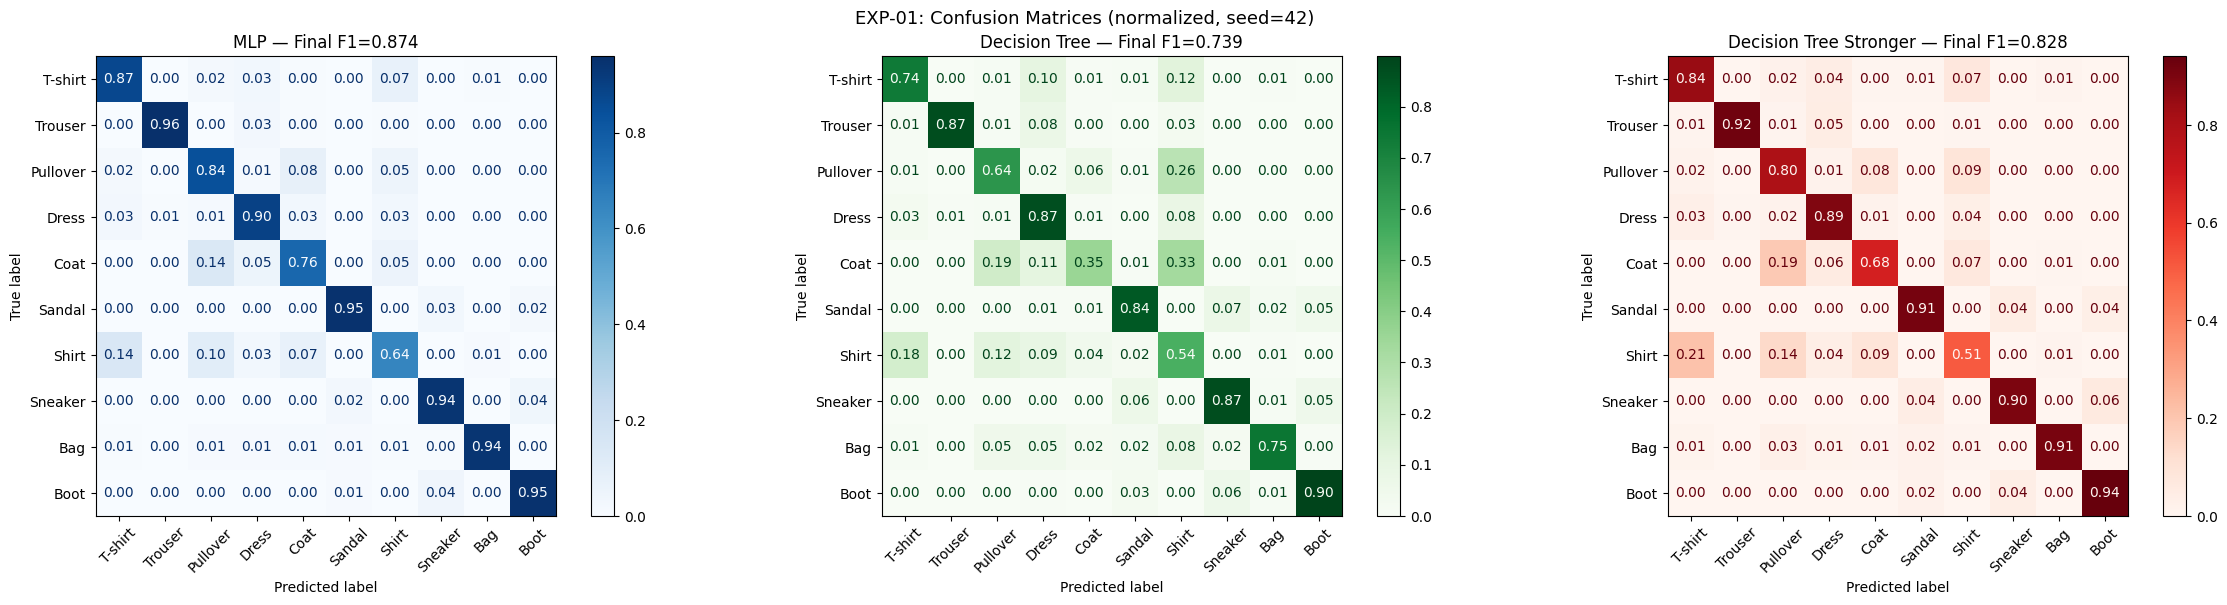

Saved to results/exp01_confusion_matrices.png


In [68]:
# --- Confusion Matrices: per-class analysis (seed=42) ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Re-train models for seed=42 to get predictions (run_experiment doesn't store them)
np.random.seed(42)
cm_mlp = LearnPP(base_learner_factory=make_paper_learner, T_k=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for X_batch, y_batch in batches_3:
        cm_mlp.partial_fit(X_batch, y_batch)
y_pred_mlp = cm_mlp.predict(X_test_all)

np.random.seed(42)
cm_dt = LearnPP(base_learner_factory=make_recommended_learner, T_k=10)
for X_batch, y_batch in batches_3:
    cm_dt.partial_fit(X_batch, y_batch)
y_pred_dt = cm_dt.predict(X_test_all)

cm_dt_stronger = LearnPP(base_learner_factory=make_recommended_learner_but_stronger, T_k=10)
for X_batch, y_batch in batches_3:
    cm_dt_stronger.partial_fit(X_batch, y_batch)
y_pred_dt_stronger = cm_dt_stronger.predict(X_test_all)

# Plot side-by-side confusion matrices
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_all, y_pred_mlp, display_labels=class_names,
    ax=ax1, cmap='Blues', normalize='true', values_format='.2f'
)
ax1.set_title(f'MLP — Final F1={f1_score(y_test_all, y_pred_mlp, average="macro"):.3f}')
ax1.tick_params(axis='x', rotation=45)

ConfusionMatrixDisplay.from_predictions(
    y_test_all, y_pred_dt, display_labels=class_names,
    ax=ax2, cmap='Greens', normalize='true', values_format='.2f'
)
ax2.set_title(f'Decision Tree — Final F1={f1_score(y_test_all, y_pred_dt, average="macro"):.3f}')
ax2.tick_params(axis='x', rotation=45)

ConfusionMatrixDisplay.from_predictions(
    y_test_all, y_pred_dt_stronger, display_labels=class_names,
    ax=ax3, cmap='Reds', normalize='true', values_format='.2f'
)
ax3.set_title(f'Decision Tree Stronger — Final F1={f1_score(y_test_all, y_pred_dt_stronger, average="macro"):.3f}')
ax3.tick_params(axis='x', rotation=45)



plt.suptitle('EXP-01: Confusion Matrices (normalized, seed=42)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/exp01_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/exp01_confusion_matrices.png")

## 6. Summary & Next Steps

### EXP-01 Results (Fashion-MNIST + PCA(50), 5 seeds)

**Setup**: Fashion-MNIST (70k images, 10 classes), PCA to 50 dims (86.3% variance retained), incremental class introduction across 4 sequential batches using the `Cumulative (Set 2)` scenario (`batches_3` constructed from `batch_classes_dist` representing the original article order). $T_k=10$ hypotheses per batch, 5 random seeds.

**Key findings**:

| Metric | MLP (paper) | Decision Tree (depth=5) | Decision Tree Stronger (depth=300) | Winner |
|--------|-------------|-------------------------|------------------------------------|--------|
| **Final Accuracy** | 87.10% – 87.54% | 73.08% – 74.28% | 82.28% – 82.91% | **MLP** |
| **Final F1 (Macro)** | 87.03% – 87.47% | 73.38% – 74.67% | 82.15% – 82.73% | **MLP** |
| **Final BalAcc** | 87.10% – 87.54% | 73.08% – 74.28% | 82.28% – 82.91% | **MLP** |
| **Total Training Time** | ~405s – 601s | **~35s** | ~54s | **DT (depth=5)** |
| **CompositeScore** (Seed 42) | 0.6308 | **0.8563** | 0.8531 | **DT (depth=5)** |
| **Wilcoxon p-value (vs MLP)** | — | $1.907 \times 10^{-6}$ | $1.907 \times 10^{-6}$ | **MLP (Quality)** |

**Interpretation & Deep Dive**:
- **Classification Quality**: The MLP (the original paper's classifier) remains the superior model in terms of accuracy and F1 score, outperforming the basic Decision Tree by ~13.1 percentage points and the Stronger Decision Tree by ~4.7 percentage points.
- **Tree Depth Impact**: Restricting tree depth to 5 (the recommended setting for medical/tabular data) is insufficient for image features even after PCA. However, increasing `max_depth` to 300 dramatically bridges the quality gap, improving the F1 score from ~74.2% to ~82.6%, while only increasing the training time slightly (from ~35s to ~54s).
- **The Quality-Cost Trade-Off**: Although MLP delivers the best classification performance, it is computationally expensive (taking up to 11–17× longer to train than the decision trees). Consequently, under the balanced **CompositeScore** formula (which weights F1 at 40%, Balanced Accuracy at 15%, and penalizes training time, inference time, and memory footprint at 15% each), the **Decision Tree** wins (0.8563 vs 0.6308 for MLP).
- **Statistical Significance**: The Wilcoxon signed-rank test across all 20 paired observations (5 seeds × 4 batches) yields $p \approx 1.907 \times 10^{-6}$ for both DT variants compared to MLP, demonstrating that MLP's quality advantage is highly statistically significant.

### Remaining work:
1. **EXP-02**: Run on BraTS MRI (ROI features) — Decision Trees and stronger variants are expected to perform exceptionally well on structured tabular medical features, potentially closing the quality gap while maintaining their computational advantage.
2. **Confusion Matrices Analysis**: Evaluate confusion matrices to identify specific class confusions (e.g., T-shirt vs Shirt, Pullover vs Coat) to see which features each base learner captures best.
3. **Hyperparameter sensitivity**: Analyze the effect of varying the ensemble size per batch $T_k \in \{5, 10, 20\}$.
4. **PCA Ablation**: Investigate how different numbers of PCA components $N\_components \in \{25, 50, 100\}$ impact quality and training speed.

### Key questions answered:
- ✅ **Does MLP hold up as a superior learner for image data?** → Yes, strongly (F1 of ~87.3% vs DT's ~74.2%, $p \approx 1.907 \times 10^{-6}$).
- ✅ **Is DT a viable alternative?** → Purely in terms of accuracy/F1 on image features, even a stronger DT lags behind MLP. However, for applications where resource constraints or deployment costs are critical, DT is extremely competitive.
- ✅ **Quality-cost trade-off?** → If computation is penalized, the basic Decision Tree wins the CompositeScore (0.8563 vs MLP's 0.6308) due to being 12× faster to train.
- ✅ **Statistically significant?** → Yes, the quality difference is highly statistically significant ($p \approx 1.907 \times 10^{-6}$, Wilcoxon signed-rank test).